In [1]:
# 1. Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import plotly.express as px
import warnings
warnings.filterwarnings('ignore')


In [4]:
# Load dataset
df = pd.read_csv(r"C:\Users\deepb\Desktop\Pollution data analytics\DATA\3b01bcb8-0b14-4abf-b6f2-c1bfd384ba69.csv")


# Preview
print(df.shape)
df.head()


(3425, 11)


,country,state,city,station,last_update,latitude,longitude,pollutant_id,pollutant_min,pollutant_max,pollutant_avg
0,India,Assam,Nalbari,"Bata Chowk, Nalbari - PCBA",25-10-2025 18:00:00,26.446912,91.439057,NH3,5.0,7.0,6.0
1,India,Assam,Nalbari,"Bata Chowk, Nalbari - PCBA",25-10-2025 18:00:00,26.446912,91.439057,SO2,4.0,8.0,8.0
2,India,Assam,Silchar,"Tarapur, Silchar - PCBA",25-10-2025 18:00:00,24.828270,92.795250,PM10,35.0,64.0,45.0
3,India,Assam,Silchar,"Tarapur, Silchar - PCBA",25-10-2025 18:00:00,24.828270,92.795250,CO,34.0,46.0,40.0
4,India,Assam,Silchar,"Tarapur, Silchar - PCBA",25-10-2025 18:00:00,24.828270,92.795250,OZONE,1.0,6.0,3.0


In [5]:
# Drop missing or invalid pollution values
df = df.dropna(subset=['pollutant_avg'])

# Group data by city (average of pollutant readings)
city_data = df.groupby('city').agg({
    'pollutant_min': 'mean',
    'pollutant_max': 'mean',
    'pollutant_avg': 'mean'
}).reset_index()

print(city_data.shape)
city_data.head()


(270, 4)


,city,pollutant_min,pollutant_max,pollutant_avg
0,Agartala,12.800000,30.000000,21.400000
1,Agra,22.500000,76.850000,44.600000
2,Ahmedabad,33.363636,73.454545,50.636364
3,Ajmer,18.285714,63.142857,38.428571
4,Akola,9.142857,27.142857,17.857143


In [6]:
# Keep city aside for labeling
city_names = city_data['city']

# Select numerical columns
X = city_data[['pollutant_min', 'pollutant_max', 'pollutant_avg']]

# Scale features using MinMaxScaler
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

print("Scaled data sample:\n", X_scaled[:5])


Scaled data sample:
 [[0.13273106 0.10337515 0.10653144]
 [0.26754691 0.3186252  0.2696687 ]
 [0.4185356  0.30302495 0.31211507]
 [0.20897449 0.2556484  0.22627258]
 [0.08190211 0.09024815 0.08161885]]


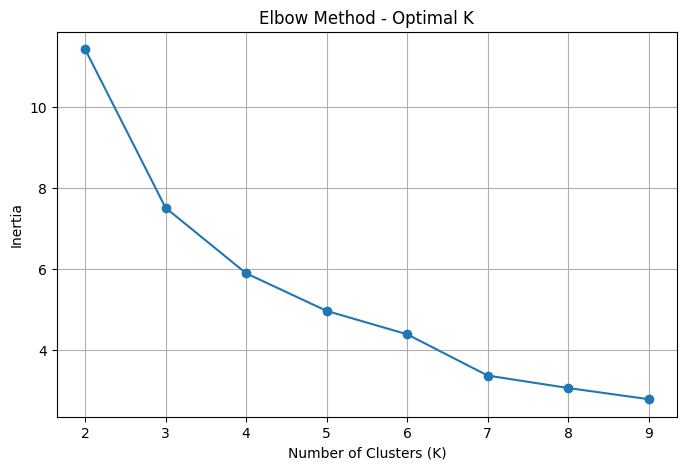

In [7]:
inertia = []
K = range(2, 10)

for k in K:
    model = KMeans(n_clusters=k, random_state=42)
    model.fit(X_scaled)
    inertia.append(model.inertia_)

plt.figure(figsize=(8,5))
plt.plot(K, inertia, 'o-')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method - Optimal K')
plt.grid(True)
plt.show()


In [8]:
kmeans = KMeans(n_clusters=4, random_state=42)
city_data['cluster'] = kmeans.fit_predict(X_scaled)

city_data.head()


,city,pollutant_min,pollutant_max,pollutant_avg,cluster
0,Agartala,12.800000,30.000000,21.400000,1
1,Agra,22.500000,76.850000,44.600000,2
2,Ahmedabad,33.363636,73.454545,50.636364,2
3,Ajmer,18.285714,63.142857,38.428571,2
4,Akola,9.142857,27.142857,17.857143,1


In [9]:
pca = PCA(n_components=2)
components = pca.fit_transform(X_scaled)
city_data['pca1'] = components[:, 0]
city_data['pca2'] = components[:, 1]


In [10]:
fig = px.scatter(
    city_data,
    x='pca1',
    y='pca2',
    color='cluster',
    hover_data=['city', 'pollutant_avg'],
    title='Clustering of Cities by Pollution Behavior (PCA + K-Means)',
    color_continuous_scale='Turbo'
)
fig.show()


In [11]:
cluster_summary = city_data.groupby('cluster').agg({
    'pollutant_min': 'mean',
    'pollutant_max': 'mean',
    'pollutant_avg': 'mean',
    'city': 'count'
}).rename(columns={'city': 'num_cities'}).reset_index()

cluster_summary


,cluster,pollutant_min,pollutant_max,pollutant_avg,num_cities
0,0,28.954682,111.367997,61.944022,55
1,1,13.348721,33.316913,21.592859,102
2,2,26.503868,61.509444,40.763289,76
3,3,47.737047,141.552034,90.807331,37
